In [1]:
# !pip install -e /files/shared/ap/jupyter-notebook/pkgs/objFuncs --break-system-packages
# !pip install -e /files/shared/ap/jupyter-notebook/pkgs/pyBO --break-system-packages

In [2]:
# !pip install -e /files/shared/ap/jupyter-notebook/pkgs/objFuncs
# !pip install -e /files/shared/ap/jupyter-notebook/pkgs/pyBO

In [3]:
# !pip install -e ../../objFuncs
# !pip install -e ../../pyBO

# large decision bound was essential!

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import time
import pandas as pd
from copy import deepcopy as copy

In [5]:
import objFuncs
from objFuncs import VM,construct_machineIO,residuals
from objFuncs.util import plot_obj_history, plot_multi_obj_history, plot_time_val

objFuncs version: 1.0.4. updated on 2024-03-26


flame_utils is not importable. ignoreing this feature...


In [6]:
decision_CSETs=['PSC2:I_CSET']
decision_min = -20
decision_max =  20

In [7]:
objective_goal = { 
    'BPM:XPOS_RD' : -111111,
}
objective_norm = {pv:1.0 for pv in objective_goal.keys()}
objective_weight = {pv:1.0 for pv in objective_goal.keys()}
objective_RDs = list(objective_goal.keys())

In [8]:
def fun(x):
    return -2*x - 111112

In [9]:
vm = VM(
        x0 = np.zeros(1),
        decision_CSETs = decision_CSETs,
        decision_min = decision_min,
        decision_max = decision_max,
        objective_RDs = ['BPM:XPOS_RD'],
        # objective_RDs_mean = [2],
        # objective_RDs_std  = [4],
        fun = fun,
        )

In [10]:
machineIO = construct_machineIO()
machineIO._ensure_set = vm.ensure_set
machineIO._fetch_data = vm.fetch_data
machineIO._caget      = vm.caget
machineIO._caput      = vm.caput
machineIO._test       = True

In [11]:
res = residuals.residualObj(  
    decision_CSETs = decision_CSETs,
    decision_min= decision_min,
    decision_max= decision_max,
    objective_goal = objective_goal,
    objective_norm = objective_norm,
    objective_weight = objective_weight,
    machineIO = machineIO,
    )

======== class info ========
init_time: 2024-06-14 08:45:34.973905
class_hierarchy: [
    residualObj, objFuncBase]
machineIO: <objFuncs.construct_machineIO.construct_machineIO object at 0x00000295BB8A38E0>
decision_CSETs: [
    PSC2:I_CSET]
decision_min: [-20.]
decision_max: [20.]
decision_bounds: [[-20.  20.]]
decision_RDs: [
    PSC2:I_RD]
decision_tols: [0.05]
decision_couplings: None
history_buffer_size: None
logging_frequency: inf
logging_tag: 
logging_fname: None
x0: [0.]

======== class info ========
init_time: 2024-06-14 08:45:34.973905
class_hierarchy: [
    residualObj, objFuncBase]
machineIO: <objFuncs.construct_machineIO.construct_machineIO object at 0x00000295BB8A3C40>
decision_CSETs: [
    PSC2:I_CSET]
decision_min: [-20.]
decision_max: [20.]
decision_bounds: [[-20.  20.]]
decision_RDs: [
    PSC2:I_RD]
decision_tols: [0.05]
decision_couplings: None
history_buffer_size: None
logging_frequency: inf
logging_tag: 
logging_fname: None
x0: [0.]
plot_time_val: <class 'objFuncs

In [12]:
# objFuncs._global_machineIO._fetch_data = machineIO_vms[0].fetch_data
# objFuncs._global_machineIO._ensure_set = machineIO_vms[0].ensure_set
# objFuncs._global_machineIO._test = True

In [13]:
plot_RDs = plot_time_val(history=machineIO.history)

plot_objs = plot_obj_history(
            res.history['objectives']
            )

plot_obj_RDs = plot_obj_history(
            res.history['objective_RDs']
            )

callbacks = [plot_RDs, plot_objs,plot_obj_RDs]

evaluation_wait_time = 0.1
def obj_callbacks(x):
    time.sleep(evaluation_wait_time)
    return obj(x,callbacks=callbacks)

# runLSQ

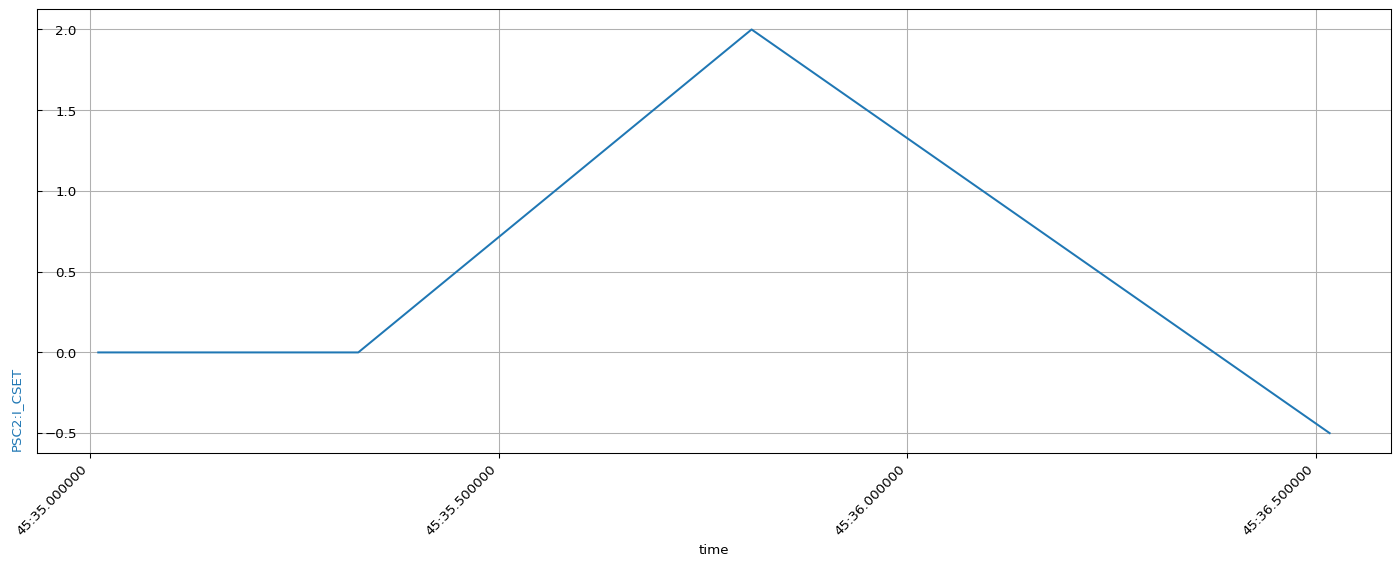

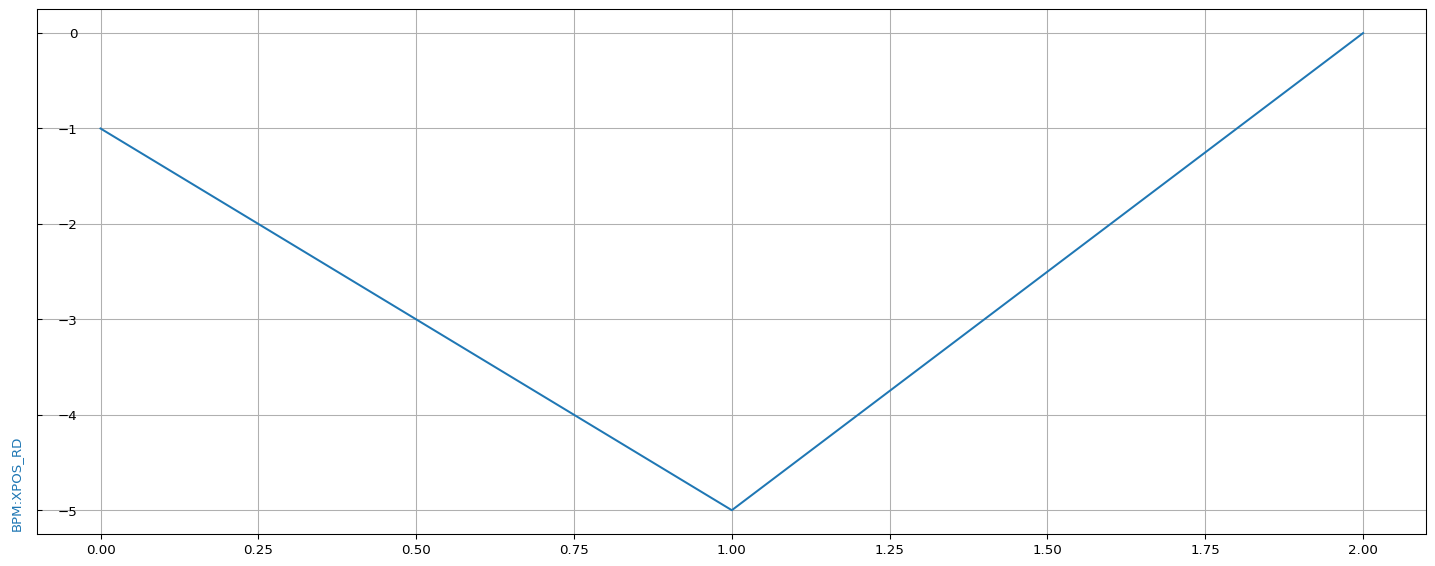

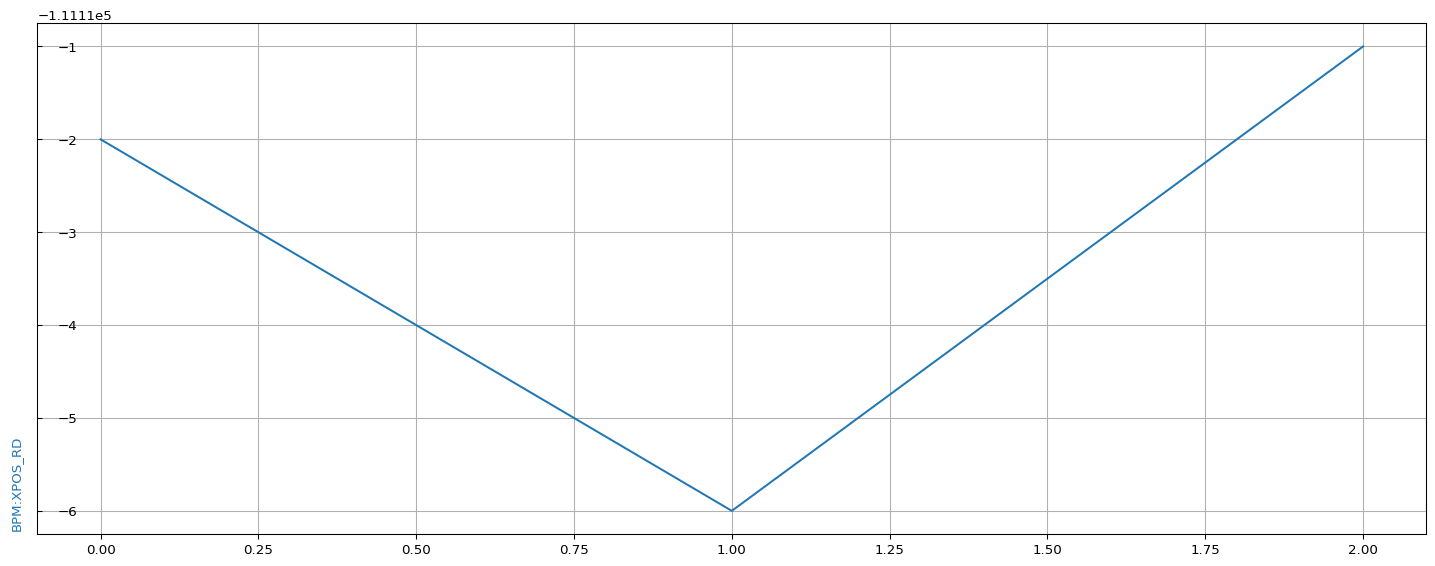

In [14]:
result = res.lsq_linear(jac_use3points=False,callbacks=callbacks)
for f in callbacks:
    f.close()

In [15]:
res.history['decision_CSETs']

{'names': ['PSC2:I_CSET'], 'values': [array([0.]), array([2.]), array([-0.5])]}

In [16]:
res.history['objective_RDs']

{'names': ['BPM:XPOS_RD'],
 'values': [array([-111112.]), array([-111116.]), array([-111111.])]}